#### Simple MLP to test whether MBE regularization could "resolve conflict"


Given:
- Two input distributions $p_1$ and $p_2$
- Initial model parameters $\theta_0$
- Parameter shift vector $\Delta\theta$

We define:
\begin{align}
\text{Positive samples} &: \{(x, f_{\theta_0 + \Delta\theta}(x)) \mid x \sim p_1\} \\
\text{Negative samples} &: \{(x, f_{\theta_0 - \Delta\theta}(x)) \mid x \sim p_2\}
\end{align}

Where $f_{\theta}(x)$ represents the output of the model with parameters $\theta$ given input $x$. Note that two distributions should NOT be the same. 


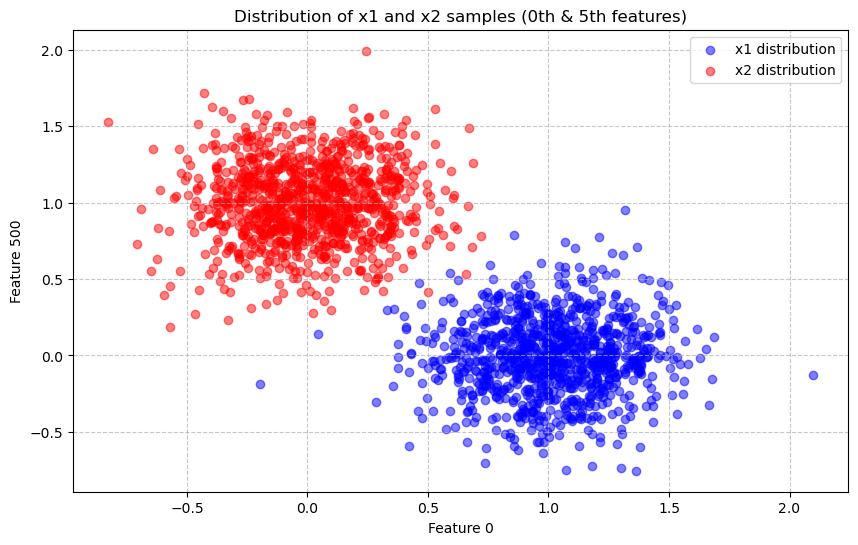

In [1]:
# initial distribution (p1 & p2)

# Define distributions p1 and p2
from src.ce_exp import sample_p1, sample_p2, plot_x1_x2

x1 = sample_p1(1000)
x2 = sample_p2(1000)
plot_x1_x2(x1, x2)


In [97]:
from src.ce_exp import * 

# Hyper-parameters 
# ------------------------------------------------------------
in_dim, hidden_dim, out_dim = 10, 20, 10 
data_size = 1000 
load_init = True
load_shift = True
exp_name = "exp_b2"
mod = "mix"
switch_phase = True

# Model initialization 
# ------------------------------------------------------------
mlp = SimpleModel(in_dim, hidden_dim, out_dim) # can we store a 'fixed' initial param, and load it every time we run experiment? 
INIT_PARAMS_PATH = 'initial_mlp_params.pt'
if load_init: 
    mlp.load_state_dict(torch.load(INIT_PARAMS_PATH))  # Load fixed parameters
else: 
    torch.save(mlp.state_dict(), INIT_PARAMS_PATH)
    
# Load Original Parameters for comparison purpose
# ------------------------------------------------------------
mlp_original = SimpleModel(in_dim, hidden_dim, out_dim)
mlp_original.load_state_dict(torch.load(INIT_PARAMS_PATH))

# Build 'Conflicting' dataset
# ------------------------------------------------------------
PARAM_SHIFT_PATH = "param_shift.pkl"
if load_shift: 
    param_shift = load_param_shift(PARAM_SHIFT_PATH)
else: 
    param_shift = None 
trainset, valset, param_shift = build_dataset(500, 100, mlp, in_dim, param_shift)


# Different Learning approaches 
# ------------------------------------------------------------
# (a). Train with P samples, then N samples 
# Initialize optimizer
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.01)
epochs = 1000
batch_size = 32
train_accumulation_steps = batch_size // 1
val_interval = 10
val_steps = 10

# GAPT
# ------------------------------------------------------------
from src.gapt import GatedPhaseTransition
gapt = GatedPhaseTransition(p_m=100, p_a=5, min_a=0.15)
# ------------------------------------------------------------


# Train with positive samples first, then negative samples
print("Training with positive samples first, then negative samples")

loss_record = defaultdict(list)
frames = [] 

# Positive samples training
for epoch in range(epochs):
    group_name = decide_group_name(epoch, epochs, mod="negative->positive")
    if epoch % val_interval == 0: 
        val_loss, similarity_metrics = validate(mlp, mlp_original, param_shift, valset, val_steps)
        for name, value in val_loss.items(): 
            loss_record[name].append(value.item())
        for name, value in similarity_metrics.items(): 
            loss_record[name].append(value)
        log_str = build_log_str(epoch, epochs, mod, val_loss, similarity_metrics)
        print(log_str)            
        frame, specialized = neuron_specialization_frame(mlp, trainset, batch_size, group_name, epoch)
        frames.append(frame)
        
        # continue
    
    for accum_step in range(train_accumulation_steps): 
        x_batch, y_batch = get_batch(trainset, group_name)
        optimizer.zero_grad()
        loss_dict = mlp.compute_loss(x_batch, y_batch)
        loss = gapt.step(loss_dict['l1'], loss_dict['mbe'])
        # loss = loss_dict["l1"]
        # loss = loss_dict["l1"] + loss_dict["mbe"].clamp(min=0.10)
        # loss.backward()
        

    optimizer.step()
    mlp.zero_grad(set_to_none=True)


- Dataset constructed with 600 positive & negative samples
Training with positive samples first, then negative samples
 Epoch 1/1000,  | l1 positive loss: 0.4824 | mbe positive loss: 0.1090 | param shift similarity positive : 0.0000 | rep similarity positive : 0.5527 | l1 negative loss: 0.4496 | mbe negative loss: 0.2230 | param shift similarity negative : 0.0000 | rep similarity negative : 0.6172
 Epoch 11/1000,  | l1 positive loss: 0.4815 | mbe positive loss: 0.1132 | param shift similarity positive : 0.0000 | rep similarity positive : 0.5557 | l1 negative loss: 0.4513 | mbe negative loss: 0.2242 | param shift similarity negative : 0.0000 | rep similarity negative : 0.6148
 Epoch 21/1000,  | l1 positive loss: 0.4841 | mbe positive loss: 0.1107 | param shift similarity positive : 0.0000 | rep similarity positive : 0.5529 | l1 negative loss: 0.4504 | mbe negative loss: 0.2216 | param shift similarity negative : 0.0000 | rep similarity negative : 0.6175
 Epoch 31/1000,  | l1 positive lo

In [ ]:
# Alleviating in catastrophic forgetting with GAPT

# Pos (l1: 0.02) -> Neg
# pos l1: 0.78 | pos mbe: 0.20 | neg l1: 0.03 | neg mbe: 0.18
# (GAPT pm=100, pa=5, min_a=0.1) Pos -> Neg 
# pos l1: 0.68 | pos mbe: 0.14 | neg l1: 0.03 | neg mbe: 0.09
# 13.1% reduction in catastrophic forgetting with GAPT

# Neg (l1: 0.015) -> Pos
# neg l1: 0.98 | neg mbe: 0.14 | pos l1: 0.03 | pos mbe: 0.32
# (GAPT pm=100, pa=5, min_a=0.15) Neg -> Pos
# neg l1: 0.70 | neg mbe: 0.20 | pos l1: 0.03 | pos mbe: 0.15
# 29% reduction in catastrophic forgetting with GAPT

In [96]:
((0.98 - 0.70)) / (0.98 - 0.015), (0.78 - 0.68) / (0.78 - 0.02)

(0.2901554404145078, 0.13157894736842102)

In [22]:
save_path = f"logs/{exp_name}_neuron_specialization.gif"
print(f"Saving animation to {save_path}...")
fps = 4
duration = int(1000 / fps)  # Convert fps to duration in ms
frames[0].save(
    save_path,
    save_all=True,
    append_images=frames[1:],
    optimize=False,
    duration=duration,
    loop=0
)
print(f"Animation saved successfully to {save_path}")

Saving animation to logs/exp_b2_neuron_specialization.gif...
Animation saved successfully to logs/exp_b2_neuron_specialization.gif


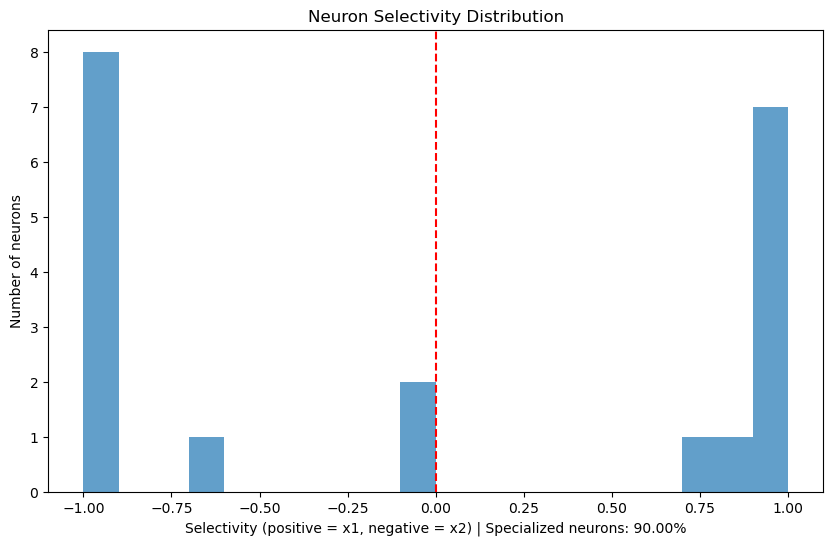

{'between_distance': 1.606107234954834, 'within_variance': 0.14777785539627075, 'separation_ratio': 4.178013801574707, 'specialized_score': 0.8999999761581421}


<Figure size 640x480 with 0 Axes>

In [98]:
from src.ce_exp import * 

# visualize_representations(mlp, valset, batch_size=32)
# visualize_representations_umap(mlp, valset, batch_size=32)
# visualize_representations_tsne(mlp, valset, batch_size=32)
separation_metrics = measure_separation(mlp, valset, batch_size=32)
specialized_score = neuron_specialization(mlp, valset, batch_size=32, save_path="logs/exp_a4_neuron_specialization.png")
separation_metrics['specialized_score'] = specialized_score
print(separation_metrics)

In [5]:
from PIL import Image
import os

# Paths to the GIF files
gif1_path = 'logs/exp_a7_neuron_specialization.gif'
gif2_path = 'logs/exp_a8_neuron_specialization.gif'
output_path = 'logs/combined_neuron_specialization.gif'

# Load the GIFs
gif1 = Image.open(gif1_path)
gif2 = Image.open(gif2_path)

# Get the number of frames in each GIF
def get_frame_count(gif):
    frames = 0
    try:
        while True:
            gif.seek(frames)
            frames += 1
    except EOFError:
        pass
    gif.seek(0)  # Reset to first frame
    return frames

n_frames1 = get_frame_count(gif1)
n_frames2 = get_frame_count(gif2)

# Use the minimum number of frames between the two GIFs
n_frames = min(n_frames1, n_frames2)

# Create new frames by combining images side by side
combined_frames = []
for i in range(n_frames):
    # Get current frames
    gif1.seek(i)
    gif2.seek(i)
    frame1 = gif1.copy().convert('RGBA')
    frame2 = gif2.copy().convert('RGBA')
    
    # Create a new image with enough width for both frames
    width = frame1.width + frame2.width
    height = max(frame1.height, frame2.height)
    combined = Image.new('RGBA', (width, height))
    
    # Paste the frames side by side
    combined.paste(frame1, (0, 0))
    combined.paste(frame2, (frame1.width, 0))
    
    combined_frames.append(combined)

# Save the combined GIF
fps = 4  # Use the same FPS as in your original code
duration = int(1000 / fps)  # Convert fps to duration in ms
combined_frames[0].save(
    output_path,
    save_all=True,
    append_images=combined_frames[1:],
    optimize=False,
    duration=duration,
    loop=0
)

print(f"Combined GIF saved to {output_path}")


Combined GIF saved to logs/combined_neuron_specialization.gif


In [2]:
import os 
import pickle 
from src.utils import plot_dual_metrics

log_dir = "logs"

plot_dual_metrics(loss_record, names=(f'l1_positive', f'l1_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_l1_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'mbe_positive', f'mbe_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_mbe_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'param_shift_cosine_similarity_positive', f'param_shift_cosine_similarity_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_param_shift_sim_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'rep_cosine_similarity_positive', f'rep_cosine_similarity_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_rep_sim_pos_neg.png"), same_scale=True)

# save loss record 
with open(os.path.join(log_dir, f"{exp_name}_loss_record.pkl"), "wb") as f: 
    pickle.dump(loss_record, f)

Plotting metrics: l1_positive and l1_negative...
Using same scale for both axes: [0.0262, 0.7365]
- Plot saved to logs/exp_a8_l1_pos_neg.png
Plotting metrics: mbe_positive and mbe_negative...
Using same scale for both axes: [0.0147, 0.3788]
- Plot saved to logs/exp_a8_mbe_pos_neg.png
Plotting metrics: param_shift_cosine_similarity_positive and param_shift_cosine_similarity_negative...
Using same scale for both axes: [-0.0295, 0.0295]
- Plot saved to logs/exp_a8_param_shift_sim_pos_neg.png
Plotting metrics: rep_cosine_similarity_positive and rep_cosine_similarity_negative...
Using same scale for both axes: [0.4110, 0.6349]
- Plot saved to logs/exp_a8_rep_sim_pos_neg.png


In [9]:
import os, glob 

log_dir = "logs"  # Change this to your directory path if needed

# Find all PNG files
png_files = glob.glob(os.path.join(log_dir, "*.png"))
exps = ["exp_a7", "exp_a8"]
png_files = [f for f in png_files if any(exp in f for exp in exps)]
png_files.sort()  # Sort them for consistent arrangement

idx = 3
png_files[idx::4]

['logs/exp_a7_rep_sim_pos_neg.png', 'logs/exp_a8_rep_sim_pos_neg.png']

In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread
import glob

# Directory containing the plots
log_dir = "logs"  # Change this to your directory path if needed

# Find all PNG files
# png_files = glob.glob(os.path.join(log_dir, "*.png"))
# exps = ["exp_a1", "exp_a2"]
# png_files = [f for f in png_files if any(exp in f for exp in exps)]
# png_files.sort()  # Sort them for consistent arrangement
# idx = 3
png_files = png_files[idx::4]

if not png_files:
    print(f"No PNG files found in {log_dir}")
else:
    # Calculate grid size based on number of images
    n_images = len(png_files)
    n_cols = min(2, n_images)  # Maximum 3 columns
    n_rows = (n_images + n_cols - 1) // n_cols  # Ceiling division
    
    # Create figure and subplots
    fig = plt.figure(figsize=(n_cols * 6, n_rows * 5))
    
    # Add each image to the plot
    for i, png_file in enumerate(png_files):
        ax = fig.add_subplot(n_rows, n_cols, i+1)
        
        # Read image
        img = imread(png_file)
        ax.imshow(img)
        
        # Set title from filename (cleaned up)
        basename = os.path.basename(png_file)
        title = basename.replace('.png', '').replace('_', ' ')
        ax.set_title(title)
        
        # Remove axes for cleaner look
        ax.axis('off')
    
    # Adjust spacing
    plt.tight_layout()
    
    # Save combined figure
    combined_path = os.path.join(log_dir, "combined_plots.png")
    plt.savefig(combined_path, dpi=150, bbox_inches='tight')
    print(f"Combined plot saved at: {combined_path}")
    
    # Show the figure
    plt.show()

NameError: name 'png_files' is not defined

In [ ]:
# Experiment (I). Positive dataset training --> increase in parameter shift similarity with positive param shift. 
# Experiment (II). 

In [ ]:
# Get weight in MLP param 

# Sample a bunch of input samples 

# 1. Data preparation 
# Design a "shift" in the param space 
# - Apply shift to param, use resulting model to get output (targets) for all inputs 
# - Revert that 'shift' (Or just rotate it with near 180 degree) to obtain 'negative samples'
# This would give us a pair of datasets, which is nagatively aligned with each other in its 'loss's gradient over parameter'
# loss should be simple L1 loss

# 2. Training
# - Train with A, then B. 
# - Train with B, then A. 
# - Interleaved Training (A->B->A->B... or even just mix A & B together etc ...)
# - PGS-enhanced MBE regularization (Algo 3.a)
# - PBRS (Algo 3.c)
# - Phase transition (Algo 3.b)


# 3. Evaluation
# 1. L1 loss
# 2. MBE loss 
# 3. Gradient conflicts? (Intermediate gradient conflict, if we could observe it after 'resolving conflicting' in compression phase would be nice)
